# Refined Exploratory Analysis and ML Insights
## FAOSTAT Producer Prices, Global Food Price Shocks, and Exposure Risk

This notebook keeps Chaitya's original EDA direction, but strengthens it in three ways:

1. Uses a consistent **Magma** visual palette for accessibility and visual coherence.
2. Adds deeper analysis beyond descriptive charts: crisis uplift, commodity-to-FFPI transmission, data-quality sensitivity, undernourishment-based exposure, and country clustering.
3. Provides machine-learning recommendations grounded in what the dataset can and cannot support.

**Important framing:** this is an exposure and prioritisation analysis. It does not prove direct bilateral dependence on Australia or New Zealand because bilateral trade flows are not included.

---
## 0. Setup and Load Data

**Improvement from Chaitya version:** standardises the notebook environment, uses repo-relative paths, and applies a shared Magma palette so all analysis outputs feel consistent and presentation-ready.

In [1]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from openpyxl import load_workbook

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

CMAP = mpl.colormaps['magma']
MAGMA = [mpl.colors.to_hex(CMAP(x)) for x in np.linspace(0.08, 0.92, 8)]
COLORS = {
    'AUS': MAGMA[1],
    'NZL': MAGMA[5],
    'accent': MAGMA[6],
    'dark': MAGMA[0],
    'mid': MAGMA[3],
    'light': MAGMA[7],
    'grey': '#6b7280',
}

CRISIS_PERIODS = [
    (2007, 2009, '2007-09 food crisis'),
    (2010, 2012, '2010-11 Arab Spring'),
    (2021, 2023, '2022 Ukraine war'),
]

FFPI_COLS = ['ffpi_food', 'ffpi_meat', 'ffpi_dairy', 'ffpi_cereals', 'ffpi_oils', 'ffpi_sugar']


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'README.md').exists() and (candidate / 'data').exists():
            return candidate
    return start.resolve()

ROOT_DIR = find_repo_root(Path.cwd())
DATA_DIR = ROOT_DIR / 'data' / 'processed'
RAW_DIR = ROOT_DIR / 'data' / 'raw'

master_usd = pd.read_csv(DATA_DIR / 'master_producer_prices_usd.csv')
master_idx = pd.read_csv(DATA_DIR / 'master_producer_price_index.csv')
ffpi_a = pd.read_csv(DATA_DIR / 'ffpi_annual.csv')
ffpi_m = pd.read_csv(DATA_DIR / 'ffpi_monthly.csv', parse_dates=['date'])
ghi = pd.read_csv(DATA_DIR / 'ghi_cleaned.csv')
wb = pd.read_csv(DATA_DIR / 'worldbank_food_import_pct.csv')

for df in [master_usd, master_idx, ffpi_a, ffpi_m, ghi, wb]:
    for col in df.columns:
        if col in ['year', 'value', 'food_import_pct', 'ghi_2000', 'ghi_2008', 'ghi_2016', 'ghi_2025'] or col.startswith('ffpi_'):
            df[col] = pd.to_numeric(df[col], errors='coerce')

for df in [master_usd, master_idx]:
    for col in ['is_imputed', 'is_outlier']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().map({'true': True, 'false': False}).fillna(False)

aus = master_usd[master_usd['iso3'] == 'AUS'].copy()
nzl = master_usd[master_usd['iso3'] == 'NZL'].copy()

print(f'Repo root: {ROOT_DIR}')
print(f'Master USD: {master_usd.shape[0]:,} rows x {master_usd.shape[1]} columns')
print(f'Price index: {master_idx.shape[0]:,} rows')
print(f'FFPI annual range: {int(ffpi_a.year.min())}-{int(ffpi_a.year.max())}')
print(f'GHI countries with 2025 score: {ghi.ghi_2025.notna().sum():,}')
print(f'World Bank food-import rows: {len(wb):,}')


Repo root: C:\Users\ThinkPad\Projects\assignment3-faostat-viz
Master USD: 3,033 rows x 27 columns
Price index: 6,532 rows
FFPI annual range: 1990-2026
GHI countries with 2025 score: 98
World Bank food-import rows: 9,984


---
## 1. Dataset Health Check

**Improvement from Chaitya version:** moves beyond shape/column checks by quantifying imputed rows and outlier flags, which helps defend why we keep shock observations rather than dropping them.

This section keeps the original overview, but adds interpretation: what is reliable, what is missing by design, and where joins could bias later analysis.

In [2]:

coverage = (
    master_usd.groupby(['iso3', 'country'])
    .agg(first_year=('year', 'min'), last_year=('year', 'max'), rows=('value', 'size'),
         commodities=('item', 'nunique'), imputed_rows=('is_imputed', 'sum'), outlier_rows=('is_outlier', 'sum'))
    .reset_index()
)
coverage['imputed_pct'] = coverage['imputed_rows'] / coverage['rows'] * 100
coverage['outlier_pct'] = coverage['outlier_rows'] / coverage['rows'] * 100
coverage.round(2)


,iso3,country,first_year,last_year,rows,commodities,imputed_rows,outlier_rows,imputed_pct,outlier_pct
0,AUS,Australia,1991,2024,2131,92,3,20,0.14,0.94
1,NZL,New Zealand,1991,2024,902,51,1,4,0.11,0.44


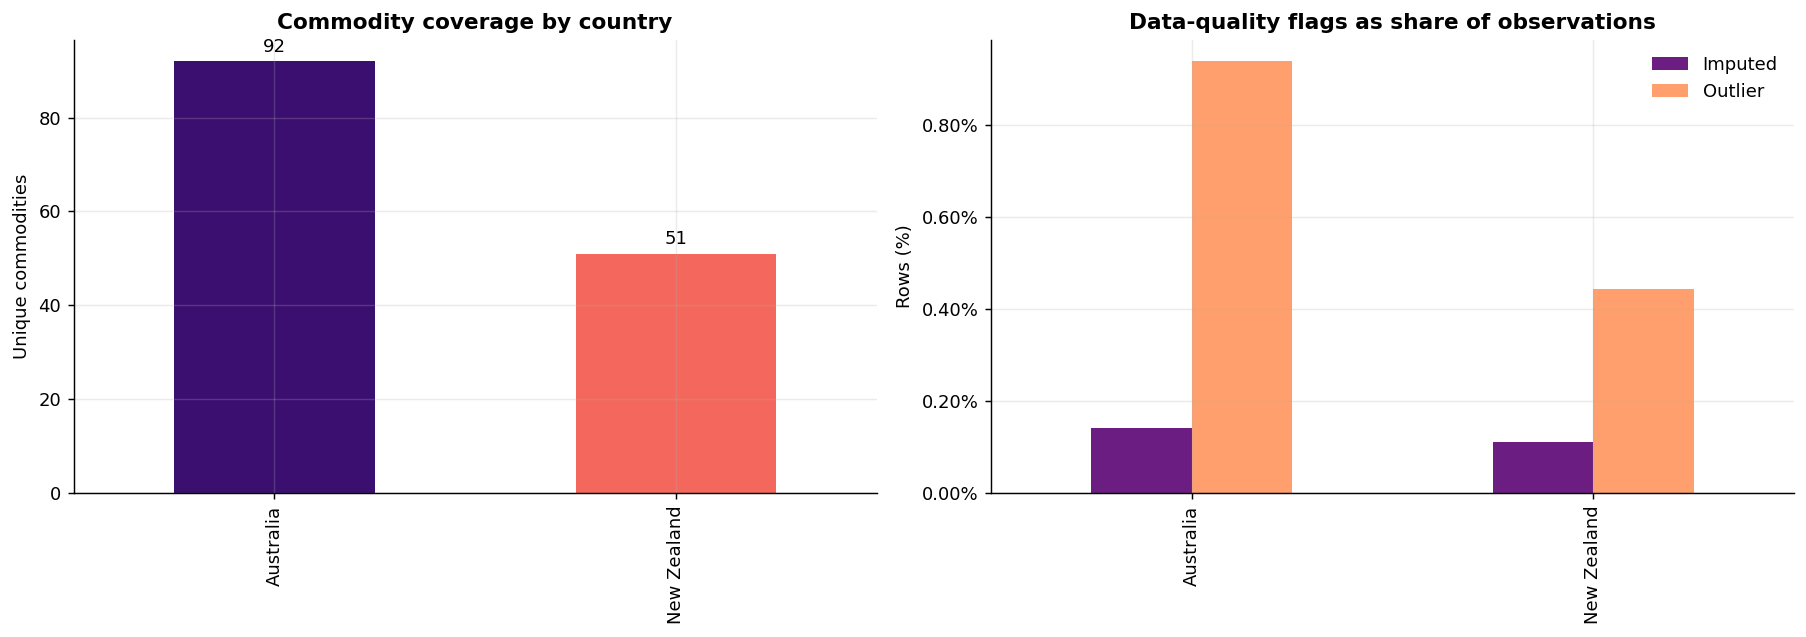

Interpretation: imputed values are retained but flagged. Outliers are also retained because price shocks are part of the story, not data errors by default.


In [3]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coverage.plot(kind='bar', x='country', y='commodities', ax=axes[0], color=[COLORS['AUS'], COLORS['NZL']], legend=False)
axes[0].set_title('Commodity coverage by country')
axes[0].set_xlabel('')
axes[0].set_ylabel('Unique commodities')
axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3)

quality = coverage.set_index('country')[['imputed_pct', 'outlier_pct']]
quality.plot(kind='bar', ax=axes[1], color=[MAGMA[2], MAGMA[6]])
axes[1].set_title('Data-quality flags as share of observations')
axes[1].set_xlabel('')
axes[1].set_ylabel('Rows (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(['Imputed', 'Outlier'], frameon=False)

plt.tight_layout()
plt.show()

print('Interpretation: imputed values are retained but flagged. Outliers are also retained because price shocks are part of the story, not data errors by default.')


---
## 2. Commodity Price Structure

**Improvement from Chaitya version:** keeps the commodity ranking analysis but adds scale-adjusted volatility using coefficient of variation, so high price and high instability are not confused.

The original notebook showed the most expensive and most volatile commodities. This version adds a second lens: which commodity groups are volatile after controlling for different price scales.

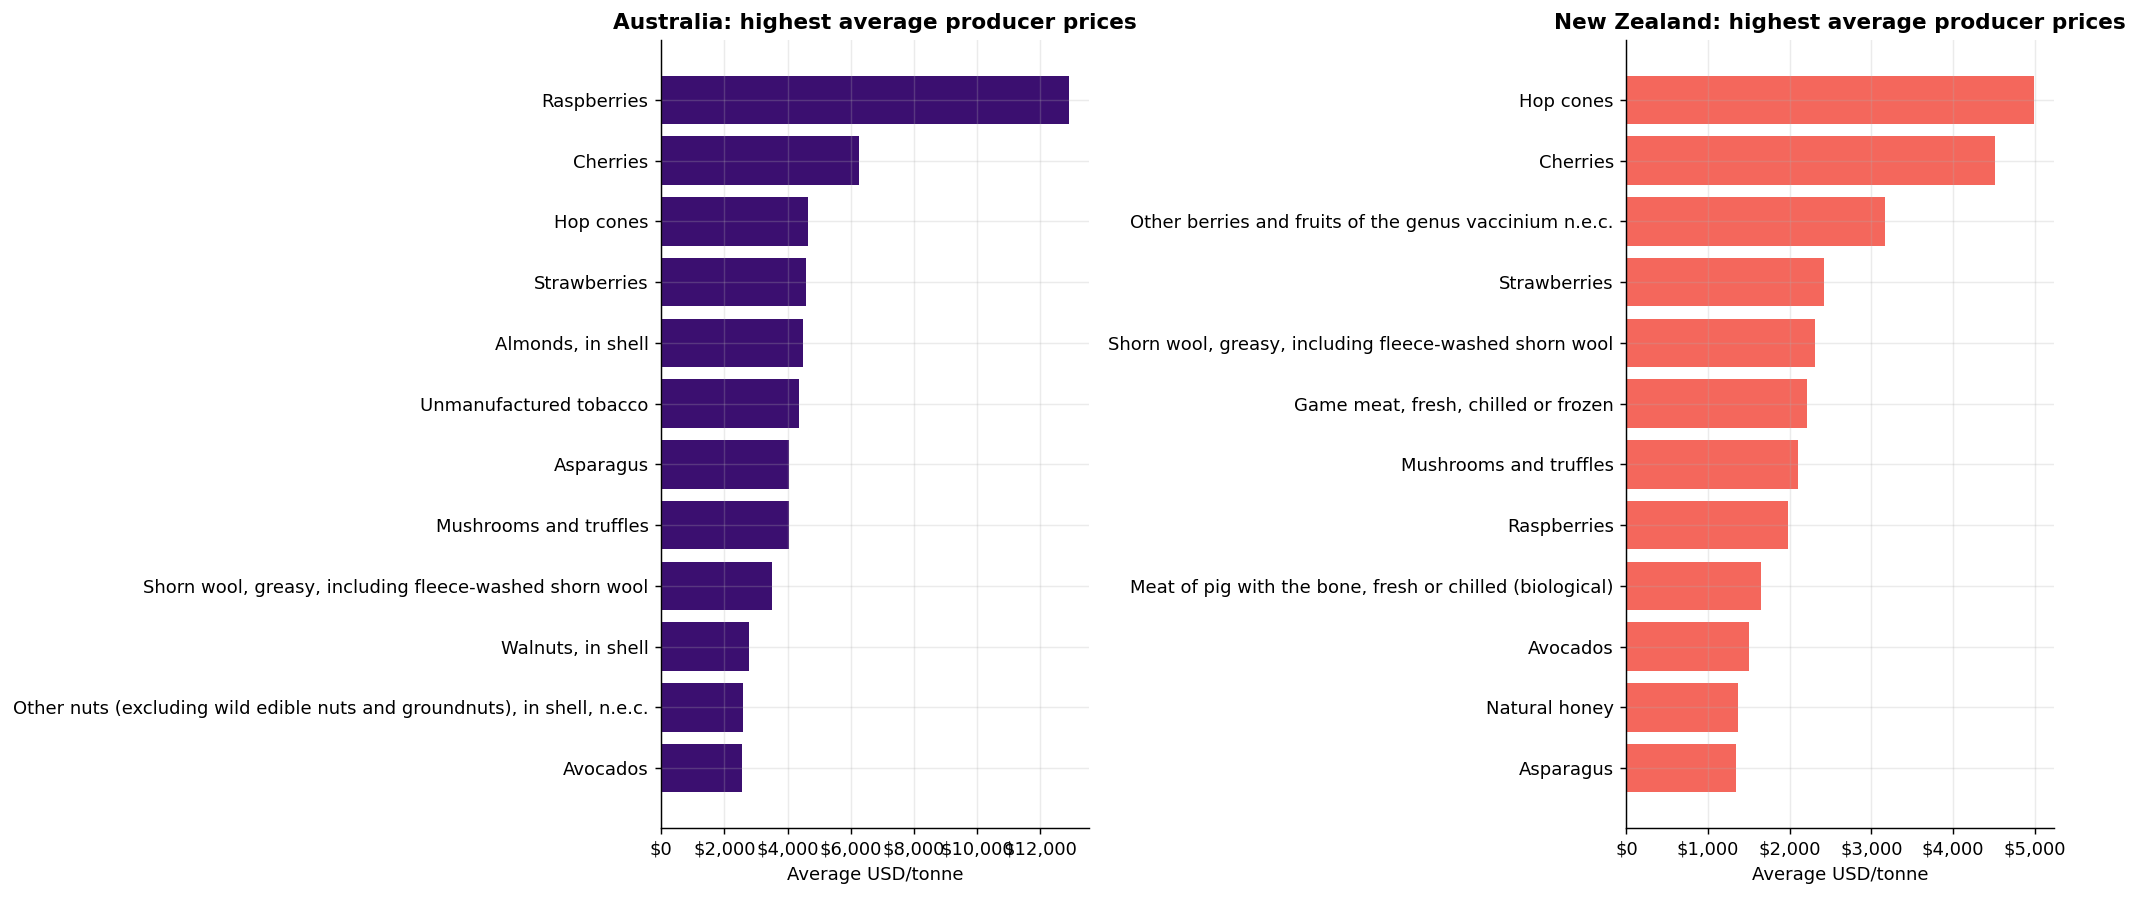

,country,item,mean,std,cv_pct,range_ratio,n
61,Australia,"Peas, green",405.03,411.42,101.58,16.63,27
25,Australia,Grapes,664.15,514.71,77.50,9.87,34
71,Australia,Raspberries,12891.43,8721.95,67.66,7.89,21
29,Australia,Hop cones,4635.64,3040.67,65.59,6.19,19
45,Australia,"Meat of sheep, fresh or chilled",2292.53,1484.45,64.75,9.01,30
31,Australia,Lemons and limes,785.66,495.72,63.10,6.49,22
139,New Zealand,Sweet potatoes,836.42,503.35,60.18,5.75,8
57,Australia,Papayas,982.39,578.05,58.84,7.11,21
54,Australia,"Other beans, green",1937.51,1118.28,57.72,6.66,31
66,Australia,Pomelos and grapefruits,571.62,329.82,57.70,5.34,21


In [4]:

def commodity_stats(df):
    stats = (
        df.groupby(['iso3', 'country', 'item'])['value']
        .agg(mean='mean', median='median', std='std', min='min', max='max', n='count')
        .reset_index()
    )
    stats['cv_pct'] = stats['std'] / stats['mean'] * 100
    stats['range_ratio'] = stats['max'] / stats['min']
    return stats[stats['n'] >= 8].replace([np.inf, -np.inf], np.nan)

stats = commodity_stats(master_usd)
top_expensive = stats.sort_values('mean', ascending=False).groupby('country').head(12)
top_volatile = stats.sort_values('cv_pct', ascending=False).groupby('country').head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, country, color in [(axes[0], 'Australia', COLORS['AUS']), (axes[1], 'New Zealand', COLORS['NZL'])]:
    d = top_expensive[top_expensive['country'] == country].sort_values('mean')
    ax.barh(d['item'], d['mean'], color=color)
    ax.set_title(f'{country}: highest average producer prices')
    ax.set_xlabel('Average USD/tonne')
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

display(top_volatile[['country', 'item', 'mean', 'std', 'cv_pct', 'range_ratio', 'n']].round(2))


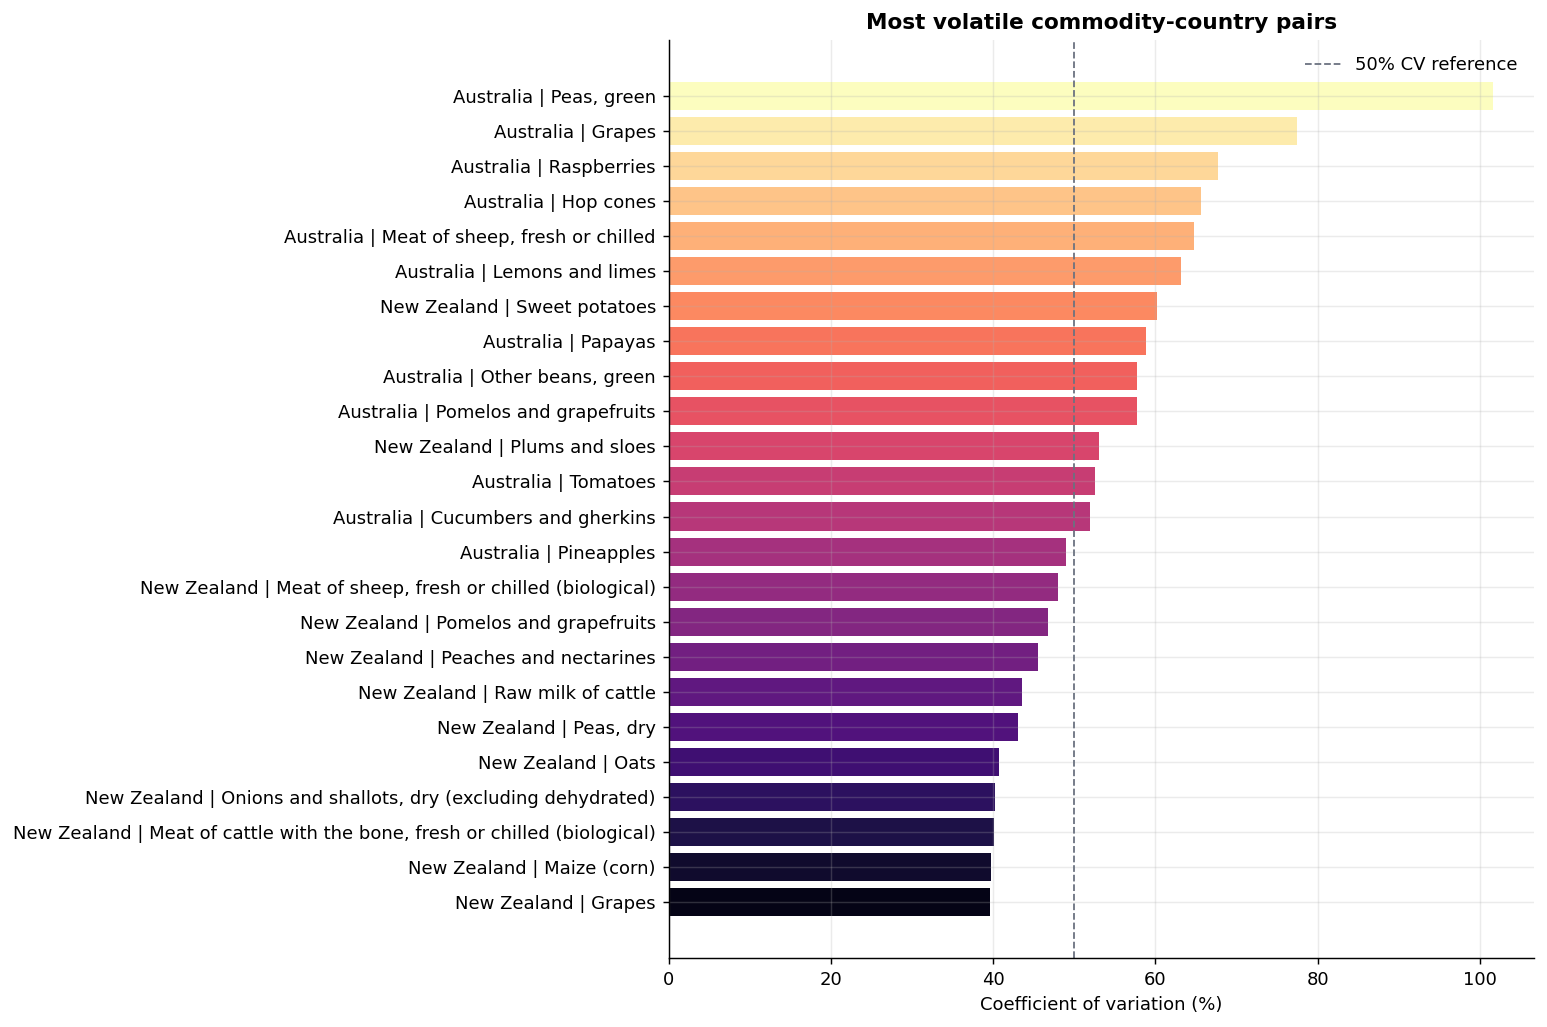

Deep-dive insight: high average price and high volatility are not the same thing. CV highlights instability after normalising by each commodity's typical price level.


In [5]:

fig, ax = plt.subplots(figsize=(12, 8))
plot = top_volatile.sort_values('cv_pct').copy()
colors = plot['cv_pct'].rank(pct=True).map(lambda x: mpl.colors.to_hex(CMAP(x)))
ax.barh(plot['country'] + ' | ' + plot['item'], plot['cv_pct'], color=colors)
ax.axvline(50, color=COLORS['grey'], linestyle='--', linewidth=1, label='50% CV reference')
ax.set_title('Most volatile commodity-country pairs')
ax.set_xlabel('Coefficient of variation (%)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Deep-dive insight: high average price and high volatility are not the same thing. CV highlights instability after normalising by each commodity\'s typical price level.')


---
## 3. Crisis-Period Uplift Analysis

**Improvement from Chaitya version:** turns crisis annotations into a measurable diagnostic by comparing commodity prices during global shock windows against non-crisis years.

Instead of only drawing crisis bands, estimate whether prices were materially higher during global shock windows.

,country,crisis,median,mean,count
0,Australia,2007-09 food crisis,48.05,57.68,83
1,Australia,2010-11 Arab Spring,83.45,102.13,72
2,Australia,2022 Ukraine war,60.02,83.71,63
3,New Zealand,2007-09 food crisis,24.81,31.17,27
4,New Zealand,2010-11 Arab Spring,67.91,71.57,14
5,New Zealand,2022 Ukraine war,68.39,64.31,14


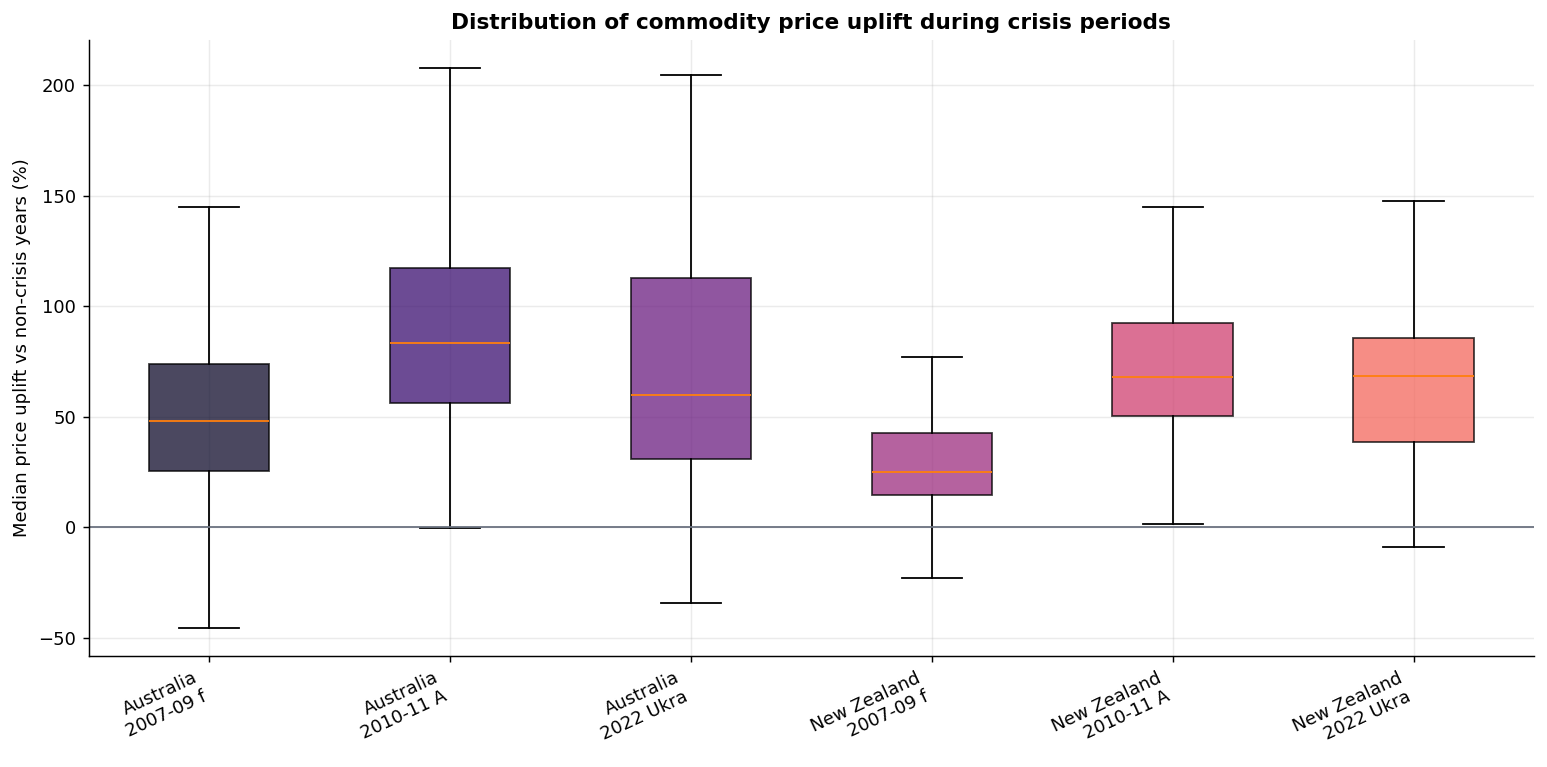

In [6]:

def crisis_label(year):
    for start, end, label in CRISIS_PERIODS:
        if start <= year <= end:
            return label
    return 'Non-crisis years'

crisis_df = master_usd.copy()
crisis_df['period'] = crisis_df['year'].apply(crisis_label)

pair_period = (
    crisis_df.groupby(['country', 'item', 'period'])['value']
    .median()
    .reset_index()
    .pivot_table(index=['country', 'item'], columns='period', values='value')
    .reset_index()
)

non = pair_period['Non-crisis years']
for _, _, label in CRISIS_PERIODS:
    if label in pair_period.columns:
        pair_period[f'{label} uplift_pct'] = (pair_period[label] / non - 1) * 100

uplift_cols = [c for c in pair_period.columns if c.endswith('uplift_pct')]
uplift_long = pair_period.melt(id_vars=['country', 'item'], value_vars=uplift_cols,
                               var_name='crisis', value_name='uplift_pct').dropna()
uplift_long['crisis'] = uplift_long['crisis'].str.replace(' uplift_pct', '', regex=False)

summary = uplift_long.groupby(['country', 'crisis'])['uplift_pct'].agg(['median', 'mean', 'count']).reset_index()
display(summary.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
box_data = [g['uplift_pct'].clip(-100, 300) for _, g in uplift_long.groupby(['country', 'crisis'])]
labels = [f'{country}\n{crisis[:9]}' for (country, crisis), _ in uplift_long.groupby(['country', 'crisis'])]
bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(MAGMA[i % len(MAGMA)])
    patch.set_alpha(0.75)
ax.axhline(0, color=COLORS['grey'], linewidth=1)
ax.set_title('Distribution of commodity price uplift during crisis periods')
ax.set_ylabel('Median price uplift vs non-crisis years (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


In [7]:

print('Top crisis-sensitive commodity pairs:')
crisis_sensitive = uplift_long.sort_values('uplift_pct', ascending=False).head(20)
display(crisis_sensitive.round(2))

print('Interpretation: this is descriptive, not causal. It helps identify commodities whose local producer prices were unusually elevated in recognised global shock windows.')


Top crisis-sensitive commodity pairs:


,country,item,crisis,uplift_pct
347,Australia,"Peas, green",2022 Ukraine war,562.22
24,Australia,Dates,2007-09 food crisis,354.72
331,Australia,"Meat of sheep, fresh or chilled",2022 Ukraine war,352.04
188,Australia,"Meat of sheep, fresh or chilled",2010-11 Arab Spring,347.71
214,Australia,Raspberries,2010-11 Arab Spring,318.88
174,Australia,Lemons and limes,2010-11 Arab Spring,307.37
200,Australia,Papayas,2010-11 Arab Spring,265.70
167,Australia,Dates,2010-11 Arab Spring,264.06
197,Australia,"Other beans, green",2010-11 Arab Spring,257.98
352,Australia,Pomelos and grapefruits,2022 Ukraine war,237.89


Interpretation: this is descriptive, not causal. It helps identify commodities whose local producer prices were unusually elevated in recognised global shock windows.


---
## 4. Commodity-to-FFPI Transmission Deep Dive

**Improvement from Chaitya version:** recalculates transmission coefficients from our current cleaned data instead of relying on static values from a separate output folder.

Chaitya's corrected methodology introduced transmission coefficients. Here we compute them from the current cleaned data rather than hard-coding them.

,iso3,country,ffpi_category,correlation,n_years,items_found
3,AUS,Australia,Oils,0.897,32,"Rape or colza seed, Soya beans, Sunflower seed"
2,AUS,Australia,Dairy,0.888,25,Raw milk of cattle
0,AUS,Australia,Cereals,0.859,34,"Barley, Maize (corn), Oats, Rice, Sorghum, Wheat"
4,AUS,Australia,Sugar,0.832,34,Sugar cane
1,AUS,Australia,Meat,0.798,30,"Meat of cattle with the bone, fresh or chilled..."
6,NZL,New Zealand,Dairy,0.934,34,Raw milk of cattle
5,NZL,New Zealand,Cereals,0.899,34,"Barley, Maize (corn), Oats, Wheat"


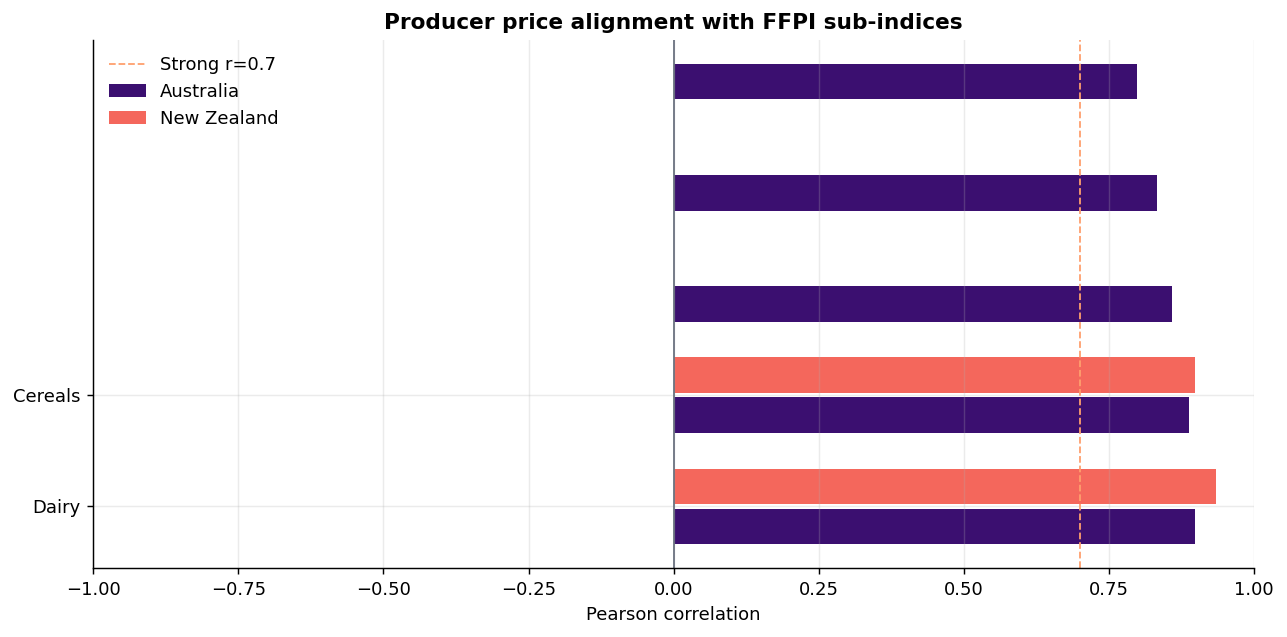

Deep-dive insight: the current cleaned data shows strong positive AUS/FFPI alignment for several mapped categories. Any fixed transmission multiplier should be recalculated from this notebook, not copied from a stale output folder.


In [8]:

ITEM_TO_FFPI = {
    'Wheat':'ffpi_cereals', 'Barley':'ffpi_cereals', 'Maize (corn)':'ffpi_cereals',
    'Rice':'ffpi_cereals', 'Oats':'ffpi_cereals', 'Sorghum':'ffpi_cereals',
    'Rape or colza seed':'ffpi_oils', 'Sunflower seed':'ffpi_oils', 'Soya beans':'ffpi_oils',
    'Sugar cane':'ffpi_sugar',
    'Meat of cattle with the bone, fresh or chilled':'ffpi_meat',
    'Meat of sheep, fresh or chilled':'ffpi_meat',
    'Meat of chickens, fresh or chilled':'ffpi_meat',
    'Raw milk of cattle':'ffpi_dairy',
}

rows = []
for iso, country_df in master_usd.groupby('iso3'):
    country_name = country_df['country'].iloc[0]
    for cat in ['ffpi_cereals', 'ffpi_meat', 'ffpi_dairy', 'ffpi_oils', 'ffpi_sugar']:
        items = [item for item, mapped in ITEM_TO_FFPI.items() if mapped == cat]
        sub = country_df[country_df['item'].isin(items)].groupby('year', as_index=False)['value'].mean()
        merged = sub.merge(ffpi_a[['year', cat]], on='year', how='inner').dropna()
        if len(merged) >= 5:
            rows.append({
                'iso3': iso,
                'country': country_name,
                'ffpi_category': cat.replace('ffpi_', '').title(),
                'correlation': merged['value'].corr(merged[cat]),
                'n_years': len(merged),
                'items_found': ', '.join(sorted(set(country_df['item']).intersection(items))),
            })

transmission = pd.DataFrame(rows).sort_values(['country', 'correlation'], ascending=[True, False])
display(transmission.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
for i, (country, d) in enumerate(transmission.groupby('country')):
    offset = -0.18 if i == 0 else 0.18
    y = np.arange(len(d)) + offset
    ax.barh(y, d['correlation'], height=0.32, label=country,
            color=COLORS['AUS'] if country == 'Australia' else COLORS['NZL'])
    ax.set_yticks(np.arange(len(d)), d['ffpi_category'])
ax.axvline(0, color=COLORS['grey'], linewidth=1)
ax.axvline(0.7, color=COLORS['accent'], linestyle='--', linewidth=1, label='Strong r=0.7')
ax.set_xlim(-1, 1)
ax.set_title('Producer price alignment with FFPI sub-indices')
ax.set_xlabel('Pearson correlation')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Deep-dive insight: the current cleaned data shows strong positive AUS/FFPI alignment for several mapped categories. Any fixed transmission multiplier should be recalculated from this notebook, not copied from a stale output folder.')


---
## 5. FFPI Lead-Lag Check

**Improvement from Chaitya version:** checks whether AUS/NZ price indices align best with previous-year, same-year, or next-year FFPI movement before using same-year dashboard overlays.

Correlation in the same year may hide timing. This check asks whether AUS/NZ price indices line up better with previous-year, same-year, or next-year FFPI.

,country,lag,correlation,n_years
0,Australia,-2,0.804,34
1,New Zealand,-2,0.784,34
2,Australia,-1,0.811,35
3,New Zealand,-1,0.814,35
4,Australia,0,0.811,35
5,New Zealand,0,0.838,35
6,Australia,1,0.789,35
7,New Zealand,1,0.829,35
8,Australia,2,0.756,34
9,New Zealand,2,0.815,34


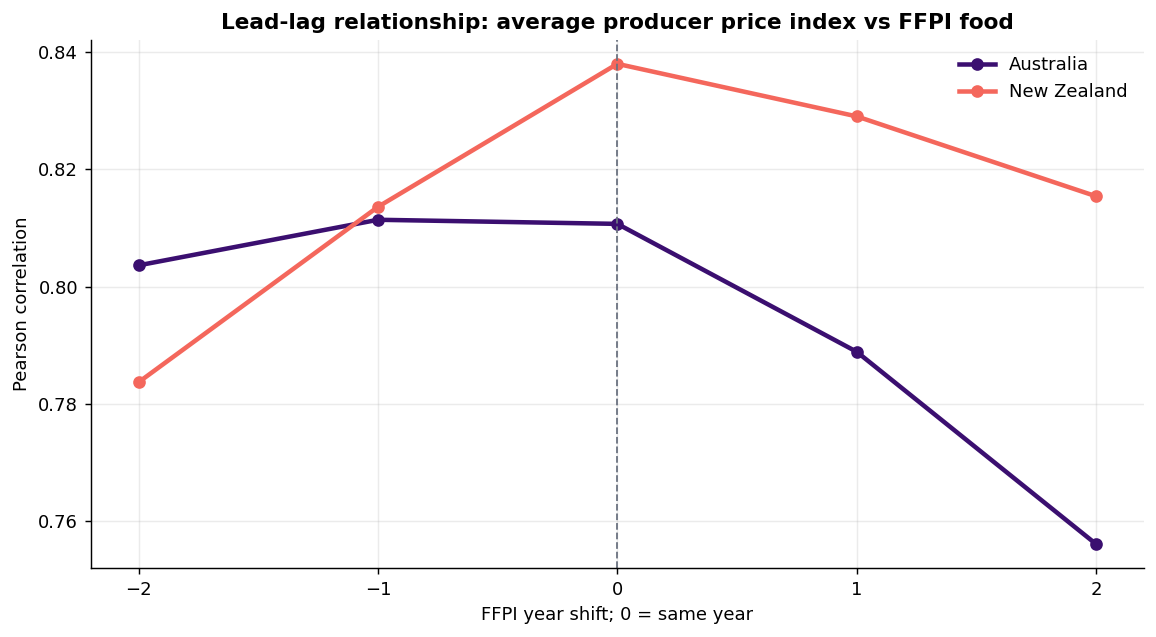

Interpretation: if lag 0 is highest, the dashboard can safely show same-year overlays. If lag +/-1 is stronger, the story should mention delayed or leading price movement.


In [9]:

def lead_lag_corr(price_df, ffpi_col='ffpi_food', max_lag=2):
    price = price_df.groupby(['iso3', 'country', 'year'], as_index=False)['value'].mean()
    rows = []
    for lag in range(-max_lag, max_lag + 1):
        tmp_ffpi = ffpi_a[['year', ffpi_col]].copy()
        tmp_ffpi['year'] = tmp_ffpi['year'] + lag
        merged = price.merge(tmp_ffpi, on='year', how='inner').dropna()
        for country, g in merged.groupby('country'):
            rows.append({'country': country, 'lag': lag, 'correlation': g['value'].corr(g[ffpi_col]), 'n_years': len(g)})
    return pd.DataFrame(rows)

lag_df = lead_lag_corr(master_idx, 'ffpi_food')
display(lag_df.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
for country, d in lag_df.groupby('country'):
    ax.plot(d['lag'], d['correlation'], marker='o', linewidth=2.5,
            color=COLORS['AUS'] if country == 'Australia' else COLORS['NZL'], label=country)
ax.axvline(0, color=COLORS['grey'], linestyle='--', linewidth=1)
ax.set_title('Lead-lag relationship: average producer price index vs FFPI food')
ax.set_xlabel('FFPI year shift; 0 = same year')
ax.set_ylabel('Pearson correlation')
ax.set_xticks(sorted(lag_df['lag'].unique()))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Interpretation: if lag 0 is highest, the dashboard can safely show same-year overlays. If lag +/-1 is stronger, the story should mention delayed or leading price movement.')


---
## 6. Vulnerability v2: Undernourishment + Food Import Dependency

**Improvement from Chaitya version:** keeps the corrected vulnerability logic but makes the hunger dimension more food-price-sensitive by using undernourishment rather than only the broad GHI score.

The original dashboard used `ghi_2025` as the hunger dimension. Chaitya's suggestion is stronger: use undernourishment because it is the GHI component most directly linked to food prices.

In [10]:

def safe_float(x):
    if isinstance(x, str):
        x = x.replace('<', '').strip()
    try:
        return float(x)
    except Exception:
        return np.nan

wb_ghi = load_workbook(RAW_DIR / 'global_hunger_index.xlsx', read_only=True, data_only=True)
ws = wb_ghi['GHI Indicator Values 2025']
indicator_rows = []
for row in ws.iter_rows(min_row=4, values_only=True):
    country = row[0]
    if country is None or len(str(country)) > 60:
        continue
    indicator_rows.append({
        'country_ghi': country,
        'undernourishment_2000': safe_float(row[1]),
        'undernourishment_2008': safe_float(row[2]),
        'undernourishment_2016': safe_float(row[3]),
        'undernourishment_2024': safe_float(row[4]),
        'child_wasting_2024': safe_float(row[11]),
        'child_stunting_2024': safe_float(row[16]),
        'child_mortality_2023': safe_float(row[20]),
    })

ghi_ind = pd.DataFrame(indicator_rows).merge(ghi[['country_ghi', 'iso3', 'ghi_2025']], on='country_ghi', how='left')
latest_wb = wb.dropna(subset=['food_import_pct']).sort_values('year').groupby('iso3', as_index=False).tail(1)

vuln2 = (
    ghi_ind.dropna(subset=['iso3'])
    .merge(latest_wb[['iso3', 'country_wb', 'year', 'food_import_pct']], on='iso3', how='inner')
)

for col in ['undernourishment_2024', 'food_import_pct', 'ghi_2025']:
    median = vuln2[col].median()
    vuln2[col] = vuln2[col].fillna(median)
    vuln2[f'{col}_norm'] = (vuln2[col] - vuln2[col].min()) / (vuln2[col].max() - vuln2[col].min())

vuln2['exposure_v2'] = (0.60 * vuln2['undernourishment_2024_norm'] + 0.40 * vuln2['food_import_pct_norm']) * 100
vuln2['exposure_original_dashboard'] = (0.60 * vuln2['ghi_2025_norm'] + 0.40 * vuln2['food_import_pct_norm']) * 100
vuln2['rank_v2'] = vuln2['exposure_v2'].rank(ascending=False, method='min')
vuln2['rank_original'] = vuln2['exposure_original_dashboard'].rank(ascending=False, method='min')
vuln2['rank_change'] = vuln2['rank_original'] - vuln2['rank_v2']

top_v2 = vuln2.sort_values('exposure_v2', ascending=False).head(15)
display(top_v2[['country_ghi', 'undernourishment_2024', 'ghi_2025', 'food_import_pct', 'year', 'exposure_v2', 'rank_change']].round(2))


,country_ghi,undernourishment_2024,ghi_2025,food_import_pct,year,exposure_v2,rank_change
52,Haiti,54.2,35.7,37.26,2016,91.85,0.0
108,Somalia,53.2,42.6,22.44,1982,76.17,1.0
50,Guinea-Bissau,22.1,25.4,41.71,2018,58.96,1.0
113,Syrian Arab Republic,39.0,30.6,21.04,2010,58.31,10.0
72,Madagascar,39.5,35.8,18.36,2024,56.26,2.0
69,Liberia,35.5,30.0,23.09,2023,56.26,7.0
23,Chad,32.0,34.8,24.27,1995,53.36,-2.0
105,Sierra Leone,24.1,28.5,32.29,2018,52.04,-2.0
27,Comoros,15.4,17.2,42.07,2023,51.54,7.0
0,Afghanistan,28.1,29.0,26.92,2019,51.42,1.0


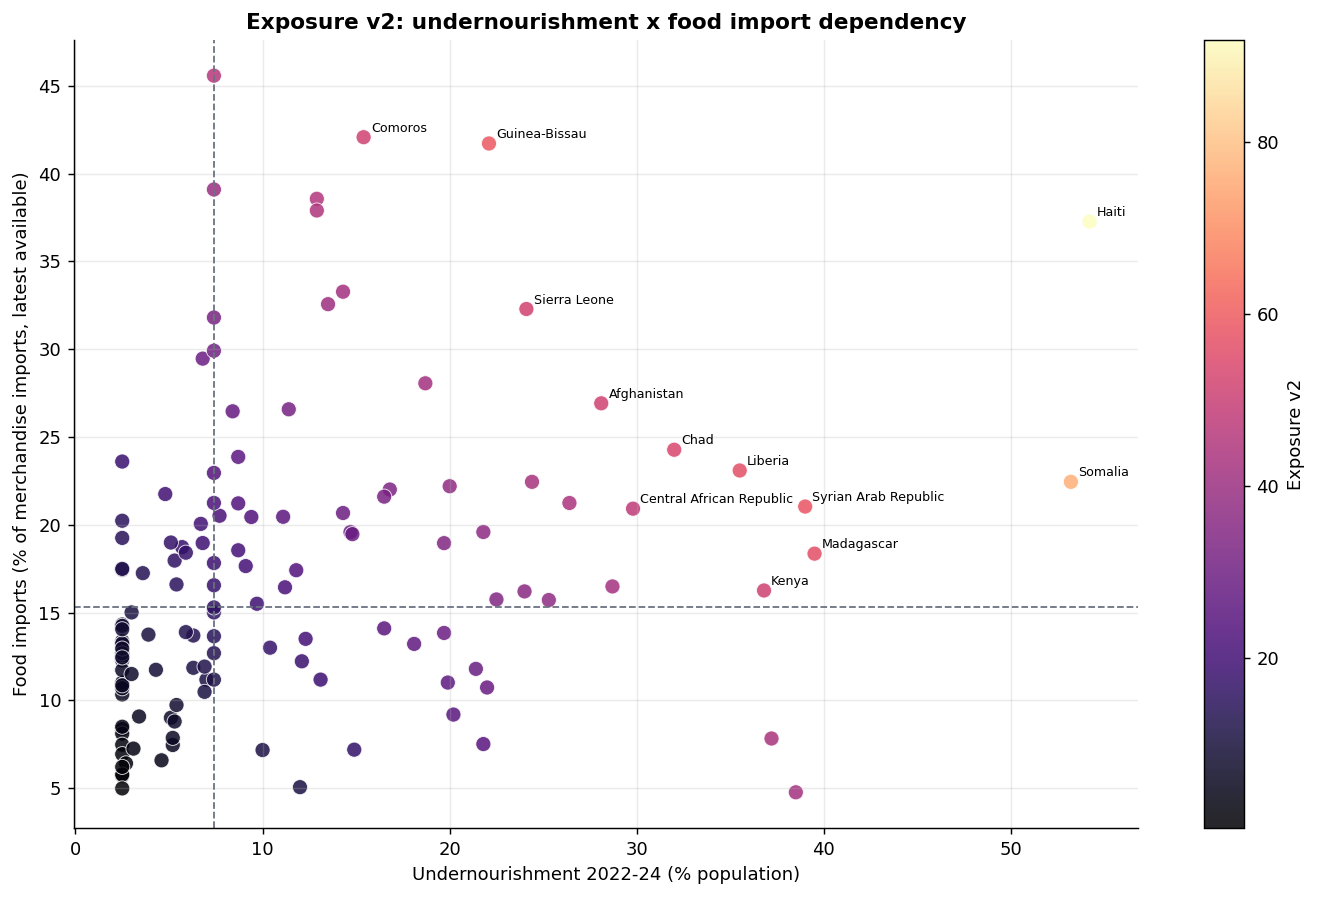

Deep-dive insight: undernourishment shifts the vulnerability lens from a broad hunger composite to the food-access component most connected to price pressure.


In [11]:

fig, ax = plt.subplots(figsize=(11, 7))
plot = vuln2.dropna(subset=['undernourishment_2024', 'food_import_pct']).copy()
sc = ax.scatter(plot['undernourishment_2024'], plot['food_import_pct'],
                c=plot['exposure_v2'], cmap='magma', s=70, alpha=0.85,
                edgecolor='white', linewidth=0.5)
for _, row in plot.sort_values('exposure_v2', ascending=False).head(12).iterrows():
    ax.annotate(row['country_ghi'], (row['undernourishment_2024'], row['food_import_pct']),
                xytext=(4, 3), textcoords='offset points', fontsize=7)
ax.axvline(plot['undernourishment_2024'].median(), color=COLORS['grey'], linestyle='--', linewidth=1)
ax.axhline(plot['food_import_pct'].median(), color=COLORS['grey'], linestyle='--', linewidth=1)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Exposure v2')
ax.set_title('Exposure v2: undernourishment x food import dependency')
ax.set_xlabel('Undernourishment 2022-24 (% population)')
ax.set_ylabel('Food imports (% of merchandise imports, latest available)')
plt.tight_layout()
plt.show()

print('Deep-dive insight: undernourishment shifts the vulnerability lens from a broad hunger composite to the food-access component most connected to price pressure.')


---
## 7. Country Exposure Clustering

**Improvement from Chaitya version:** adds segment-level insight so the dashboard can discuss exposure groups, not only a ranked country list.

A ranked list is useful, but clusters are better for storytelling because they reveal groups of countries with similar exposure profiles.

,undernourishment_2024,food_import_pct,ghi_2025,exposure_v2,countries
cluster,,,,,
3,37.71,19.97,32.99,55.76,12
0,12.42,33.70,19.68,39.88,16
2,18.50,15.49,21.50,29.08,25
1,5.22,13.50,12.22,11.72,80


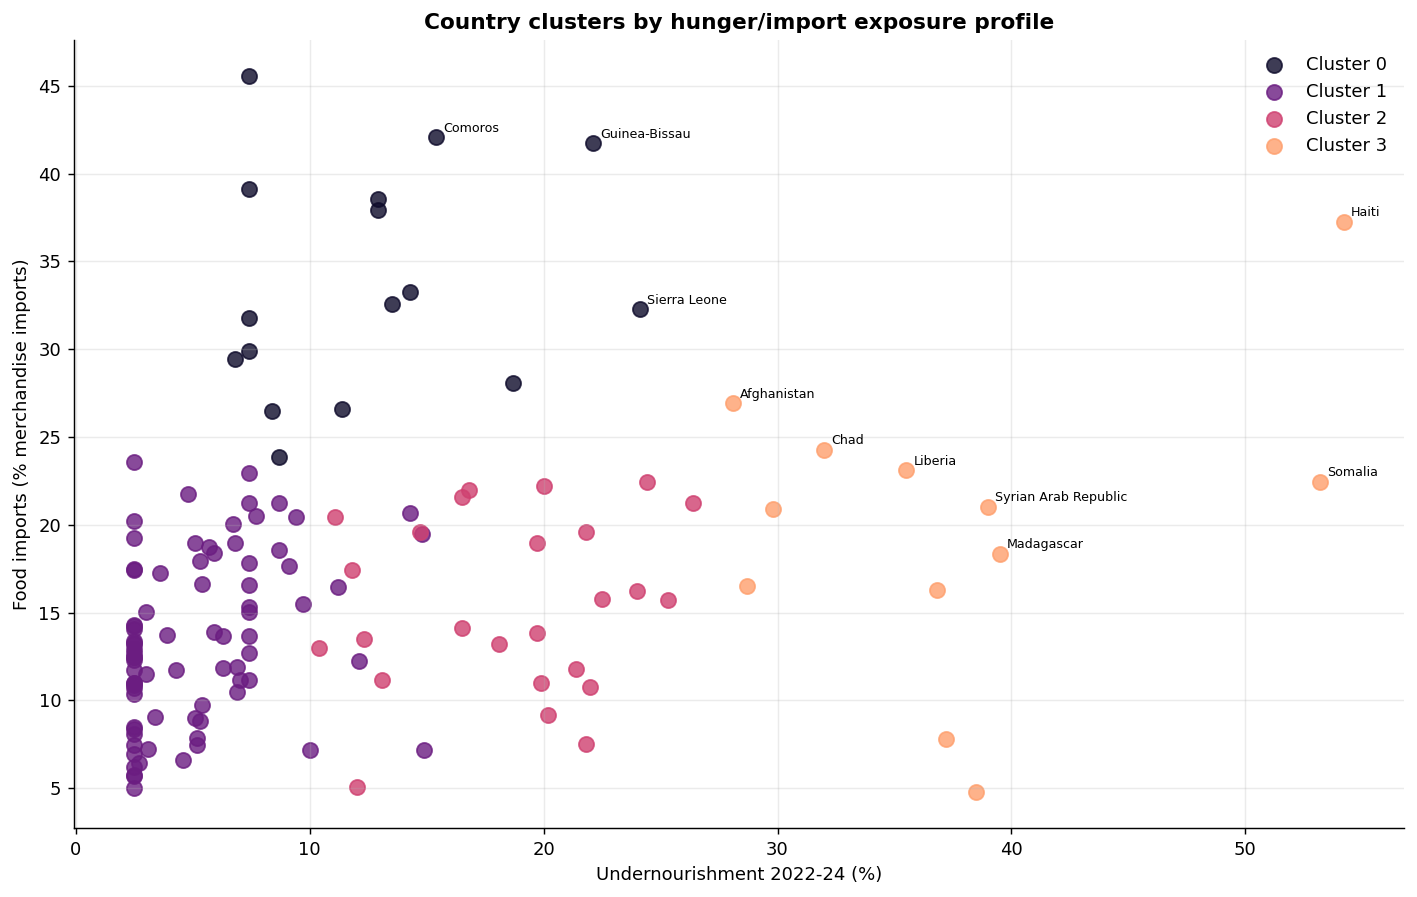

Recommended dashboard use: cluster labels can become narrative groups, for example high hunger + moderate import exposure, trade-open but lower hunger, and lower structural exposure.


In [12]:

cluster_cols = ['undernourishment_2024', 'food_import_pct', 'ghi_2025']
cluster_df = vuln2[['country_ghi', 'iso3', *cluster_cols, 'exposure_v2']].dropna().copy()

cluster_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('kmeans', KMeans(n_clusters=4, random_state=42, n_init=20)),
])
cluster_df['cluster'] = cluster_pipe.fit_predict(cluster_df[cluster_cols])
cluster_summary = cluster_df.groupby('cluster')[cluster_cols + ['exposure_v2']].mean().round(2)
cluster_summary['countries'] = cluster_df.groupby('cluster')['country_ghi'].count()
display(cluster_summary.sort_values('exposure_v2', ascending=False))

fig, ax = plt.subplots(figsize=(11, 7))
for cluster, d in cluster_df.groupby('cluster'):
    ax.scatter(d['undernourishment_2024'], d['food_import_pct'],
               s=70, alpha=0.8, label=f'Cluster {cluster}', color=MAGMA[cluster * 2])
for _, row in cluster_df.sort_values('exposure_v2', ascending=False).head(10).iterrows():
    ax.annotate(row['country_ghi'], (row['undernourishment_2024'], row['food_import_pct']),
                xytext=(4, 3), textcoords='offset points', fontsize=7)
ax.set_title('Country clusters by hunger/import exposure profile')
ax.set_xlabel('Undernourishment 2022-24 (%)')
ax.set_ylabel('Food imports (% merchandise imports)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Recommended dashboard use: cluster labels can become narrative groups, for example high hunger + moderate import exposure, trade-open but lower hunger, and lower structural exposure.')


---
## 8. What-If Scenario v2

**Improvement from Chaitya version:** keeps the conservative what-if correction, but separates baseline exposure from scenario pressure so the dashboard avoids implying a causal forecast.

The dashboard already uses a pass-through slider. This section makes the scenario more explicit and conservative, while avoiding unsupported claims about direct bilateral import flows.

,country_ghi,undernourishment_2024,food_import_pct,exposure_v2,effective_global_pressure_pct,implied_import_cost_pressure_pct,scenario_pressure_score
52,Haiti,54.2,37.261,91.854,5.0,1.863,1.711
50,Guinea-Bissau,22.1,41.710,58.962,5.0,2.086,1.230
27,Comoros,15.4,42.068,51.537,5.0,2.103,1.084
39,Eritrea,7.4,45.571,45.687,5.0,2.279,1.041
33,Djibouti,12.9,38.561,45.198,5.0,1.928,0.871
108,Somalia,53.2,22.444,76.168,5.0,1.122,0.855
88,Niger,12.9,37.894,44.544,5.0,1.895,0.844
105,Sierra Leone,24.1,32.287,52.045,5.0,1.614,0.840
130,Yemen,7.4,39.091,39.334,5.0,1.955,0.769
10,Benin,14.3,33.270,41.635,5.0,1.663,0.693


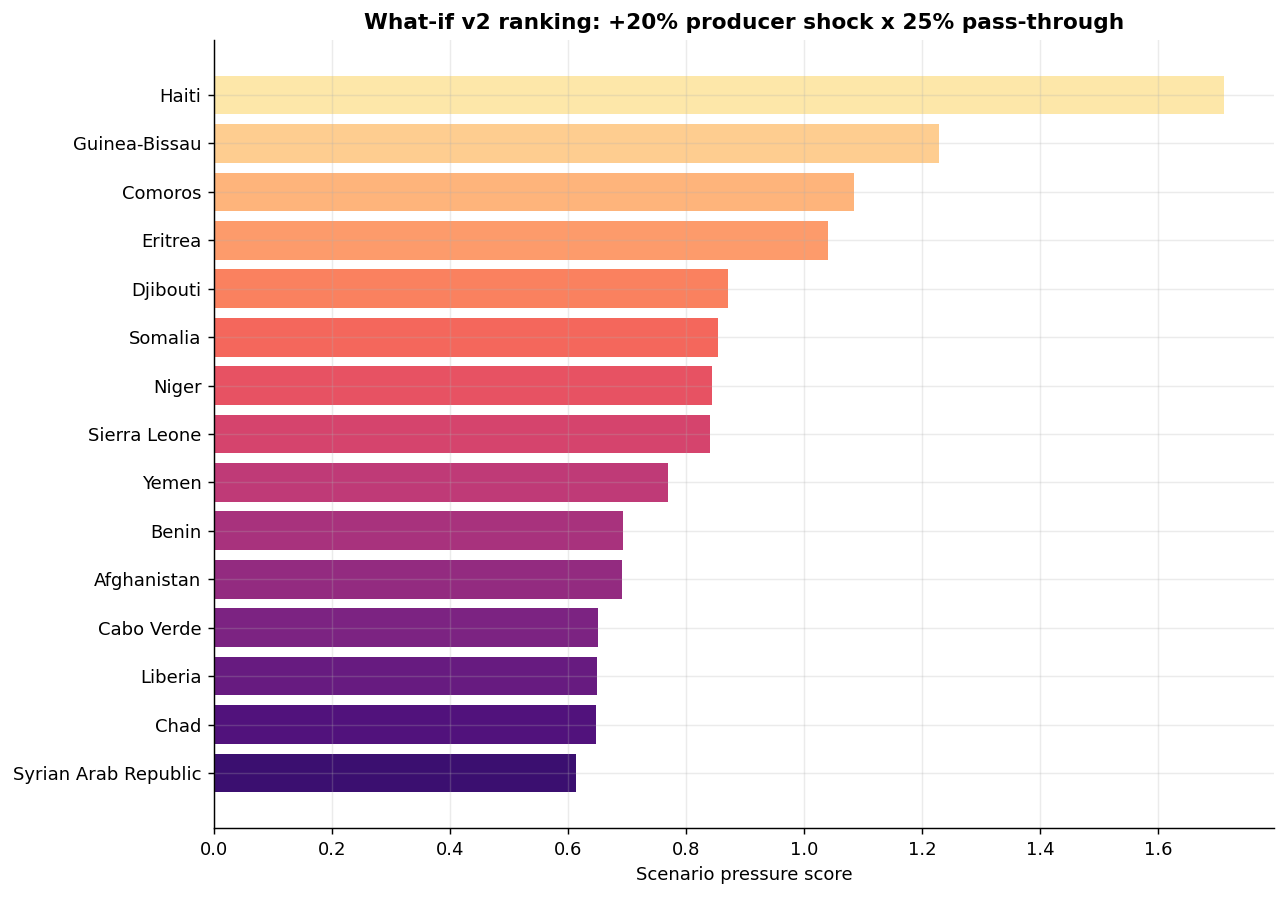

Interpretation: the scenario changes the pressure score, not the baseline location of countries in the exposure matrix. It is a prioritisation lens, not a forecast.


In [13]:

def scenario_v2(df, producer_shock_pct=20, pass_through_pct=25, transmission_coeff=None):
    out = df.copy()
    if transmission_coeff is None:
        # Current dashboard logic: shared global pressure after pass-through.
        effective_global_pressure = producer_shock_pct * pass_through_pct / 100
    else:
        # Optional research mode: include an empirically recalculated transmission coefficient.
        effective_global_pressure = producer_shock_pct * pass_through_pct / 100 * transmission_coeff
    out['effective_global_pressure_pct'] = effective_global_pressure
    out['implied_import_cost_pressure_pct'] = out['food_import_pct'] * effective_global_pressure / 100
    out['scenario_pressure_score'] = out['exposure_v2'] * out['implied_import_cost_pressure_pct'] / 100
    return out.sort_values('scenario_pressure_score', ascending=False)

scenario = scenario_v2(vuln2, producer_shock_pct=20, pass_through_pct=25)
display(scenario[['country_ghi', 'undernourishment_2024', 'food_import_pct', 'exposure_v2',
                  'effective_global_pressure_pct', 'implied_import_cost_pressure_pct', 'scenario_pressure_score']]
        .head(15).round(3))

fig, ax = plt.subplots(figsize=(10, 7))
top = scenario.head(15).sort_values('scenario_pressure_score')
colors = [mpl.colors.to_hex(CMAP(x)) for x in np.linspace(0.2, 0.95, len(top))]
ax.barh(top['country_ghi'], top['scenario_pressure_score'], color=colors)
ax.set_title('What-if v2 ranking: +20% producer shock x 25% pass-through')
ax.set_xlabel('Scenario pressure score')
plt.tight_layout()
plt.show()

print('Interpretation: the scenario changes the pressure score, not the baseline location of countries in the exposure matrix. It is a prioritisation lens, not a forecast.')


---
## 9. Machine-Learning Model Experiments

**Improvement from Chaitya version:** adds runnable model experiments with diagnostic plots so the team can choose whether ML belongs in the dashboard or only in the methodology appendix.

The dataset is useful for lightweight predictive support, but it is not large enough for over-ambitious modelling. The strongest ML uses are:

- **Forecasting or nowcasting producer price index movement** using lagged prices and FFPI features.
- **Clustering countries** into exposure profiles for narrative segmentation.
- **Anomaly detection** to flag unusual commodity-year shocks for review.
- **Scenario ranking** using transparent weighted formulas rather than black-box causal claims.

Below is a deliberately modest baseline model. Treat it as a feasibility test, not the final methodology.

,model,mean_mae_pct_points,std_mae,mean_r2,std_r2
0,Naive mean baseline,10.881,1.561,-0.003,0.002
2,Random forest,11.385,1.507,0.026,0.052
3,Extra trees,11.471,1.051,0.020,0.110
1,Ridge regression,14.310,3.112,-0.359,0.210


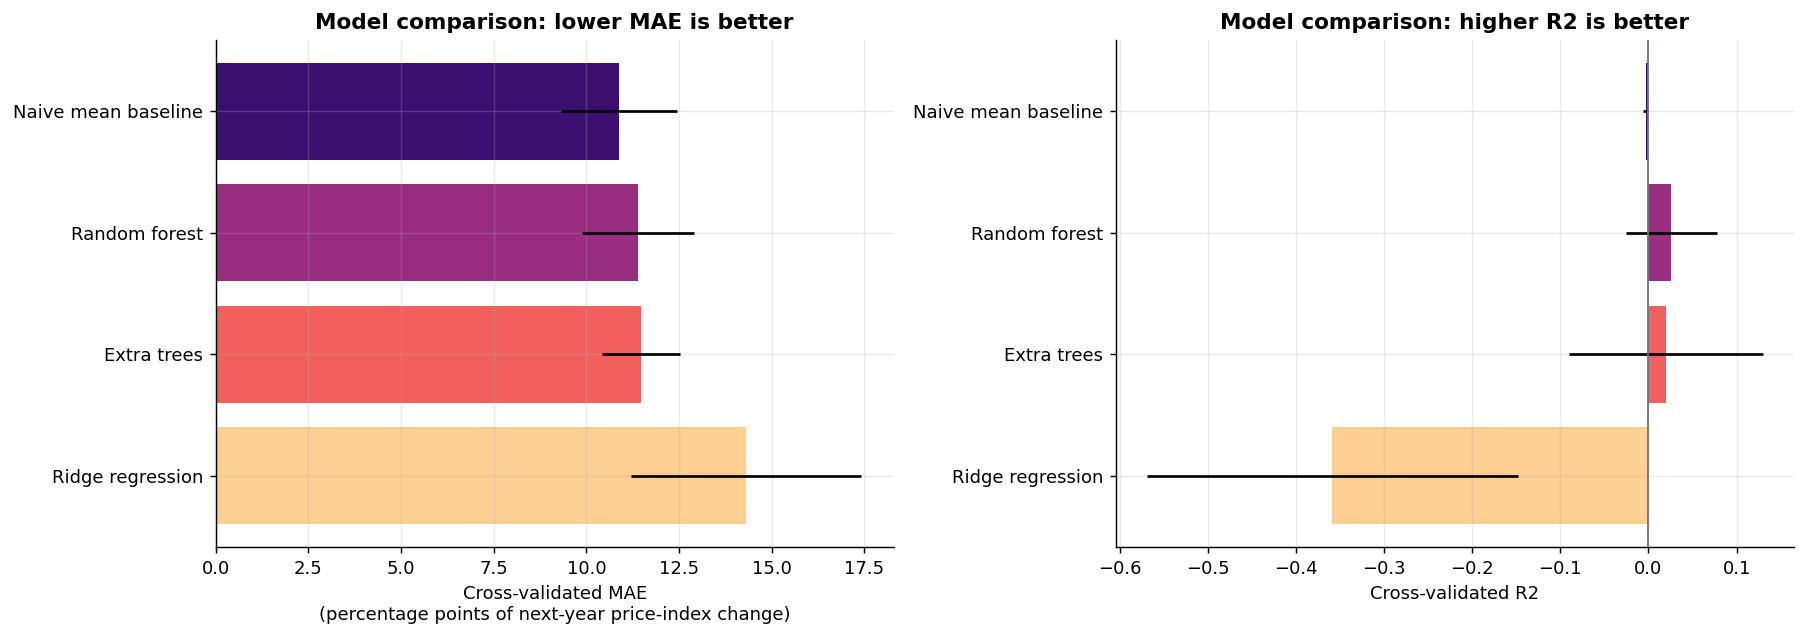

Interpretation: if tree models only modestly beat the naive baseline, ML should be used as exploratory support rather than the main dashboard claim.


In [14]:

ml = master_idx.sort_values(['year', 'iso3', 'item']).copy()
ml['lag_value'] = ml.groupby(['iso3', 'item'])['value'].shift(1)
ml['lag_ffpi_food'] = ml.groupby(['iso3', 'item'])['ffpi_food'].shift(1)
ml['target_next_value'] = ml.groupby(['iso3', 'item'])['value'].shift(-1)
ml['target_next_yoy_pct'] = (ml['target_next_value'] / ml['value'] - 1) * 100
ml = ml.dropna(subset=['value', 'lag_value', 'ffpi_food', 'lag_ffpi_food', 'target_next_yoy_pct']).copy()

features = [
    'country', 'item', 'year', 'value', 'lag_value', 'ffpi_food', 'lag_ffpi_food',
    'ffpi_cereals', 'ffpi_meat', 'ffpi_dairy', 'ffpi_oils', 'ffpi_sugar', 'is_imputed'
]
X = ml[features]
y = ml['target_next_yoy_pct']

numeric = ['year', 'value', 'lag_value', 'ffpi_food', 'lag_ffpi_food', 'ffpi_cereals', 'ffpi_meat', 'ffpi_dairy', 'ffpi_oils', 'ffpi_sugar']
categorical = ['country', 'item', 'is_imputed']

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=3), categorical),
])

models = {
    'Naive mean baseline': DummyRegressor(strategy='mean'),
    'Ridge regression': Ridge(alpha=10.0),
    'Random forest': RandomForestRegressor(n_estimators=250, min_samples_leaf=8, random_state=42, n_jobs=-1),
    'Extra trees': ExtraTreesRegressor(n_estimators=250, min_samples_leaf=8, random_state=42, n_jobs=-1),
}

tscv = TimeSeriesSplit(n_splits=5)
model_rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    mae_scores = -cross_val_score(pipe, X, y, cv=tscv, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(pipe, X, y, cv=tscv, scoring='r2')
    model_rows.append({
        'model': name,
        'mean_mae_pct_points': mae_scores.mean(),
        'std_mae': mae_scores.std(),
        'mean_r2': r2_scores.mean(),
        'std_r2': r2_scores.std(),
    })

model_results = pd.DataFrame(model_rows).sort_values('mean_mae_pct_points')
display(model_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [mpl.colors.to_hex(CMAP(x)) for x in np.linspace(0.2, 0.9, len(model_results))]

axes[0].barh(model_results['model'], model_results['mean_mae_pct_points'], xerr=model_results['std_mae'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('Model comparison: lower MAE is better')
axes[0].set_xlabel('Cross-validated MAE\n(percentage points of next-year price-index change)')

axes[1].barh(model_results['model'], model_results['mean_r2'], xerr=model_results['std_r2'], color=colors)
axes[1].invert_yaxis()
axes[1].axvline(0, color=COLORS['grey'], linewidth=1)
axes[1].set_title('Model comparison: higher R2 is better')
axes[1].set_xlabel('Cross-validated R2')

plt.tight_layout()
plt.show()

print('Interpretation: if tree models only modestly beat the naive baseline, ML should be used as exploratory support rather than the main dashboard claim.')


Random forest holdout MAE: 9.87 percentage points
Random forest holdout R2: -0.091


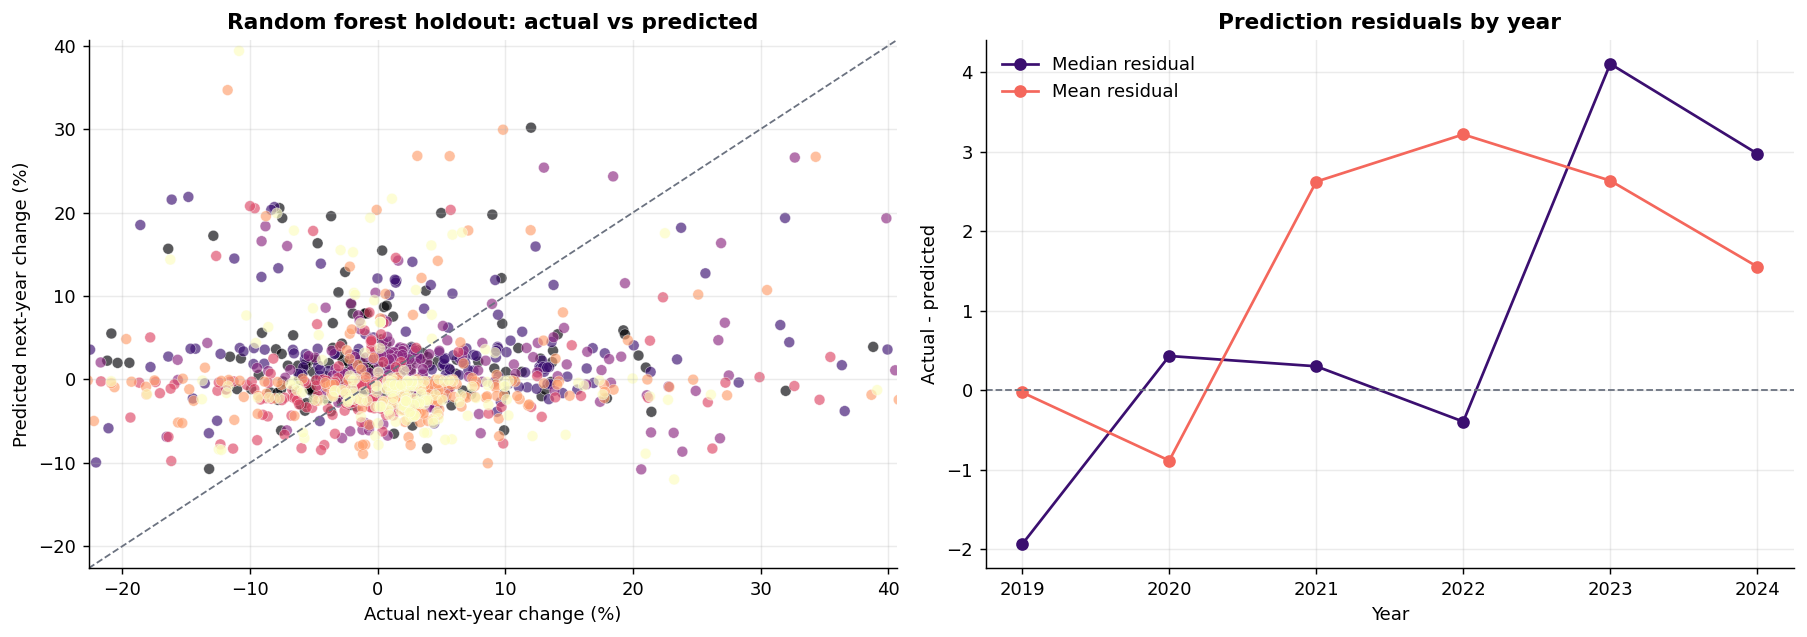

Dashboard candidate: actual-vs-predicted can be shown only as an optional ML appendix, because accuracy is useful but not strong enough for a headline forecast.


In [15]:

# Holdout-style diagnostic: train on earlier years, test on later years.
train = ml[ml['year'] <= 2018].copy()
test = ml[ml['year'] > 2018].copy()

rf_pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(n_estimators=300, min_samples_leaf=8, random_state=42, n_jobs=-1)),
])
rf_pipe.fit(train[features], train['target_next_yoy_pct'])
test = test.copy()
test['predicted_next_yoy_pct'] = rf_pipe.predict(test[features])

test_mae = mean_absolute_error(test['target_next_yoy_pct'], test['predicted_next_yoy_pct'])
test_r2 = r2_score(test['target_next_yoy_pct'], test['predicted_next_yoy_pct'])
print(f'Random forest holdout MAE: {test_mae:.2f} percentage points')
print(f'Random forest holdout R2: {test_r2:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test['target_next_yoy_pct'], test['predicted_next_yoy_pct'],
                c=test['year'], cmap='magma', alpha=0.65, edgecolor='white', linewidth=0.3)
lims = [np.nanpercentile(test[['target_next_yoy_pct', 'predicted_next_yoy_pct']].values, 1),
        np.nanpercentile(test[['target_next_yoy_pct', 'predicted_next_yoy_pct']].values, 99)]
axes[0].plot(lims, lims, color=COLORS['grey'], linestyle='--', linewidth=1)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title('Random forest holdout: actual vs predicted')
axes[0].set_xlabel('Actual next-year change (%)')
axes[0].set_ylabel('Predicted next-year change (%)')

resid_by_year = test.assign(residual=lambda d: d['target_next_yoy_pct'] - d['predicted_next_yoy_pct']).groupby('year')['residual'].agg(['median', 'mean']).reset_index()
axes[1].plot(resid_by_year['year'], resid_by_year['median'], marker='o', color=COLORS['AUS'], label='Median residual')
axes[1].plot(resid_by_year['year'], resid_by_year['mean'], marker='o', color=COLORS['NZL'], label='Mean residual')
axes[1].axhline(0, color=COLORS['grey'], linestyle='--', linewidth=1)
axes[1].set_title('Prediction residuals by year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Actual - predicted')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print('Dashboard candidate: actual-vs-predicted can be shown only as an optional ML appendix, because accuracy is useful but not strong enough for a headline forecast.')


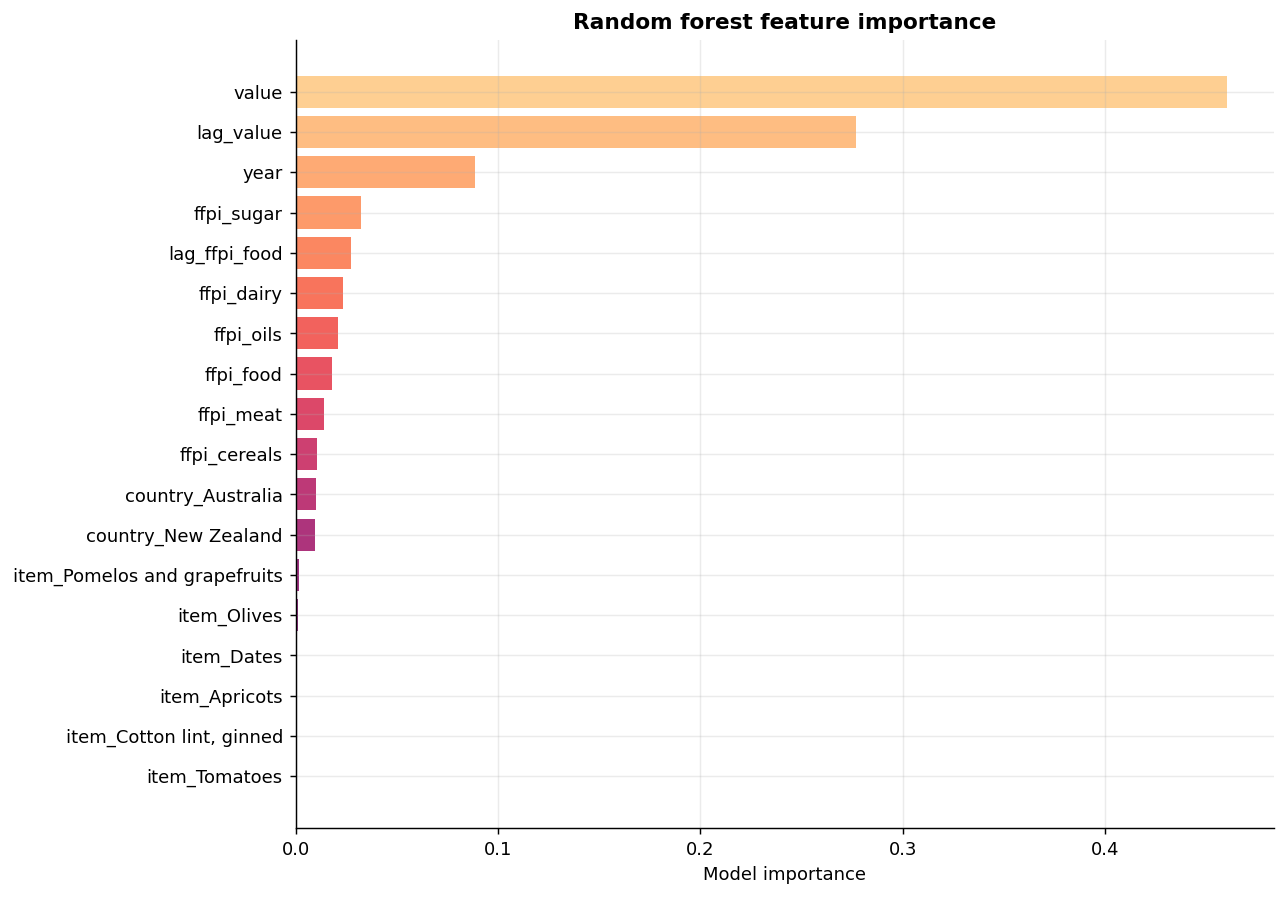

,feature,importance
1,num__value,0.460441
2,num__lag_value,0.277140
0,num__year,0.088497
9,num__ffpi_sugar,0.032468
4,num__lag_ffpi_food,0.027188
7,num__ffpi_dairy,0.023615
8,num__ffpi_oils,0.020894
3,num__ffpi_food,0.017987
6,num__ffpi_meat,0.014004
5,num__ffpi_cereals,0.010697


Interpretation: feature importance helps explain what the model uses, but it is not causal evidence.


In [16]:

# Feature importance for interpretability.
prep = rf_pipe.named_steps['prep']
model = rf_pipe.named_steps['model']
feature_names = prep.get_feature_names_out()
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).head(18)

fig, ax = plt.subplots(figsize=(10, 7))
plot_imp = importances.sort_values('importance')
ax.barh(plot_imp['feature'].str.replace('num__', '').str.replace('cat__', ''), plot_imp['importance'],
        color=[mpl.colors.to_hex(CMAP(x)) for x in np.linspace(0.25, 0.9, len(plot_imp))])
ax.set_title('Random forest feature importance')
ax.set_xlabel('Model importance')
plt.tight_layout()
plt.show()

display(importances)
print('Interpretation: feature importance helps explain what the model uses, but it is not causal evidence.')


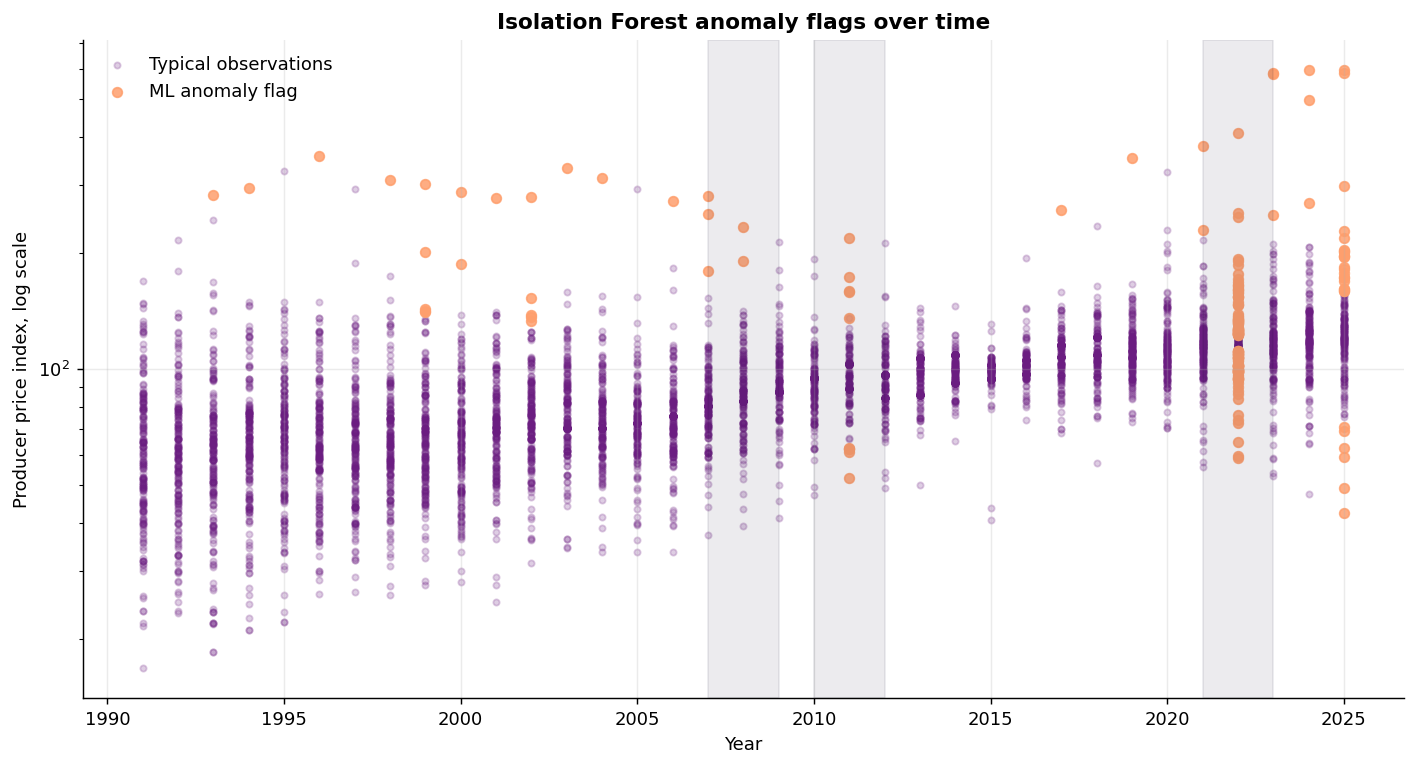

,country,item,year,value,ffpi_food,is_outlier,flag_description
2541,Australia,"Peas, green",2025,595.54,127.191617,False,Estimated value
930,Australia,Grapes,2024,593.10,121.981996,True,Estimated value
2539,Australia,"Peas, green",2023,585.76,124.519666,False,Estimated value
931,Australia,Grapes,2025,582.74,127.191617,True,Estimated value
929,Australia,Grapes,2023,580.73,124.519666,True,Estimated value
2540,Australia,"Peas, green",2024,496.39,121.981996,False,Estimated value
2538,Australia,"Peas, green",2022,409.66,144.509866,False,Estimated value
2537,Australia,"Peas, green",2021,377.70,125.734070,False,Estimated value
670,Australia,"Cotton lint, ginned",1996,356.82,77.820863,False,Estimated value
2535,Australia,"Peas, green",2019,351.19,94.931294,False,Estimated value


Dashboard candidate: anomaly flags could support a data explorer or annotations, but real crisis spikes should be reviewed rather than automatically removed.


In [17]:

# ML anomaly detection candidate: unusual producer-price-index observations.
anom = master_idx.dropna(subset=['value', 'ffpi_food']).copy()
anom_features = anom[['value', 'ffpi_food', 'ffpi_cereals', 'ffpi_meat', 'ffpi_dairy', 'ffpi_oils', 'ffpi_sugar']].ffill().bfill()
iso_model = IsolationForest(contamination=0.03, random_state=42)
anom['anomaly_flag_ml'] = iso_model.fit_predict(anom_features) == -1
ml_anomalies = anom[anom['anomaly_flag_ml']].sort_values('value', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
normal = anom[~anom['anomaly_flag_ml']]
flagged = anom[anom['anomaly_flag_ml']]
ax.scatter(normal['year'], normal['value'], s=12, alpha=0.22, color=MAGMA[2], label='Typical observations')
ax.scatter(flagged['year'], flagged['value'], s=28, alpha=0.85, color=MAGMA[6], label='ML anomaly flag')
for start, end, label in CRISIS_PERIODS:
    ax.axvspan(start, end, color=MAGMA[0], alpha=0.08)
ax.set_yscale('log')
ax.set_title('Isolation Forest anomaly flags over time')
ax.set_xlabel('Year')
ax.set_ylabel('Producer price index, log scale')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(ml_anomalies[['country', 'item', 'year', 'value', 'ffpi_food', 'is_outlier', 'flag_description']].head(20))
print('Dashboard candidate: anomaly flags could support a data explorer or annotations, but real crisis spikes should be reviewed rather than automatically removed.')


---
## 10. Recommendations for the Final Dashboard and Report

**Improvement from Chaitya version:** converts the refined EDA into dashboard-ready decisions: what to show, what to keep as caveat, and which ML outputs are defensible.

### Recommended analytical upgrades

1. Keep the normalized weighted exposure index; it is much better than raw multiplication.
2. Replace or supplement `ghi_2025` with **undernourishment 2022-24** for the exposure matrix.
3. Keep the pass-through slider, but describe it as a conservative scenario assumption.
4. Add a short note that transmission coefficients should be recalculated from current data if used.
5. Use crisis uplift and transmission results as talking points in the presentation.

### Recommended machine-learning models

| Goal | Recommended model | Why it fits | Caveat |
|---|---|---|---|
| Forecast next-year producer price movement | Random Forest / Extra Trees with lagged prices + FFPI | Handles nonlinear panel data and mixed features; now tested with comparison and holdout plots | Small yearly sample; should be supporting analysis only |
| Explain price movement transparently | Regularised linear regression / Elastic Net | Easy to explain coefficients | Less flexible for commodity-specific shocks |
| Group exposed countries | K-Means or hierarchical clustering | Useful for narrative segmentation | Cluster labels are descriptive, not causal |
| Detect unusual commodity-year shocks | Isolation Forest or robust z-score | Finds observations worth annotating | Do not automatically remove anomalies |
| Time-series forecasting for one commodity | SARIMAX with FFPI exogenous variables | Interpretable for selected commodities like wheat | Too much setup for all 96 commodities |

### Best ML visuals to consider for dashboard

1. **Model comparison bar chart**: useful if we want to show why ML is exploratory, not the main claim.
2. **Actual vs predicted scatter**: useful in an appendix or methodology tab, but not as a headline if accuracy is modest.
3. **Feature importance chart**: strongest dashboard candidate because it explains which signals the model uses.
4. **Anomaly timeline**: useful for the Data Explorer or crisis annotation section.
5. **Country clustering scatter**: strongest narrative ML-style visual because it creates clear exposure groups.

### Recommended presentation wording

> We refined the EDA from descriptive charts into a diagnostic workflow: identifying which commodities are volatile, when crisis periods lifted prices, how local producer prices align with FFPI categories, and which countries combine food-access stress with import exposure. The dashboard keeps the model transparent while leaving room for ML as a supplementary forecasting and anomaly-detection layer.